In [ ]:
from datetime import datetime

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from IPython.display import Audio, display
from matplotlib.ticker import FuncFormatter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from stonesoup.types.groundtruth import GroundTruthState

from nereus.models.environment.sound_speed_profile import Munk
from nereus.signal.ambient import WhiteNoise
from nereus.signal.anthropogenic import TonalSignal
from nereus.signal.biological import DiffuseSnappingShrimpSignal, WhaleCallSignal
from nereus.signal.effects import Reverb

sns.set_theme(style="whitegrid")

# --- Configuration Constants ---
SAMPLING_RATE = 48000 # Sampling Rate
SIGNAL_DURATION = 10.0   # Signal duration in seconds
FONT_SIZE_LABEL = 16
FONT_SIZE_TICK = 14
FIG_SIZE = (12, 6)

# --- Helper Functions ---

def khz_formatter(x, pos):
    """Format frequency axis to kHz."""
    s = f"{x/1000:.2f}"
    return s.rstrip('0').rstrip('.')

def plot_spectrogram(
        signal, sr, n_fft=4096, hop_length=1024, y_lim=None, yaxis_format='kHz',
        fig_size=FIG_SIZE
    ):
    """Generate and display a formatted spectrogram.

    Args:
        signal (np.ndarray): 1D array-like audio signal.
        sr (int): Sampling rate (Hz).
        n_fft (int): FFT window size.
        hop_length (int): STFT hop length.
        y_lim (tuple, optional): Optional (min, max) frequency limits in Hz for the
            y-axis.
        yaxis_format (str): 'kHz' to label y-axis in kHz, 'hz' for Hz.
        fig_size (tuple, optional): matplotlib figure size tuple.

    """
    # Basic validation / normalisation
    signal = np.asarray(signal)
    if signal.size == 0:
        raise ValueError("signal is empty")
    if signal.ndim > 1:
        signal = signal.flatten()
    if sr <= 0:
        raise ValueError("sr must be positive")

    # Compute STFT and convert to dB
    D = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length)
    S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

    # Create plot
    fig, ax = plt.subplots(figsize=fig_size)
    vmax = float(np.max(S_db))
    vmin = vmax - 60.0

    img = librosa.display.specshow(
        S_db,
        sr=sr,
        x_axis='time',
        y_axis='linear',
        ax=ax,
        cmap='viridis',
        hop_length=hop_length,
        vmin=vmin,
        vmax=vmax,
    )

    # Labels and ticks
    ax.set_xlabel('Time (s)', fontsize=FONT_SIZE_LABEL, labelpad=16)
    ax.tick_params(axis='both', which='major', labelsize=FONT_SIZE_TICK)

    if yaxis_format == 'kHz':
        ax.set_ylabel('Frequency (kHz)', fontsize=FONT_SIZE_LABEL, labelpad=16)
        ax.yaxis.set_major_formatter(FuncFormatter(khz_formatter))
    else:
        ax.set_ylabel('Frequency (Hz)', fontsize=FONT_SIZE_LABEL, labelpad=16)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x)}"))

    # Axis limits
    duration_s = len(signal) / float(sr)
    ax.set_xlim(0, duration_s)
    if y_lim:
        ax.set_ylim(y_lim)

    # Colorbar
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2.5%", pad=0.4)
    cbar = fig.colorbar(img, cax=cax, format='%+2.0f', label='Intensity (dB)')
    cbar.ax.yaxis.label.set_size(FONT_SIZE_LABEL)
    cbar.ax.tick_params(labelsize=FONT_SIZE_TICK)

    fig.tight_layout()
    plt.show()

# Whale Calls

We will simulate a Humpback whale call sequence using a parametric synthesiser. The song structure follows a C-A-B pattern with fundamental frequencies ranging from 250Hz to 800Hz.

In [2]:
whale_source = GroundTruthState(
    [0, 0, 0, 0],
    timestamp=datetime.now(),
    metadata={
        'amplitude_upa': 10**(180 / 20),
    }
)

# A theme is a list of frequency steps (Hz) from the previous point
theme_0 = [15, -15, 15, -15]      # Slight warble
theme_1 = [10, 0]                 # Slight rise then flat
theme_2 = [-20, -10, 10]          # Sharp fall then slight rise
theme_3 = [0, 0, 0, 0]            # Flat theme

# A phrase is a list of theme indices
phrase_A = [0, 1]              # Sings theme 0, then theme 1
phrase_B = [2, 1]              # Sings theme 2, then theme 1
phrase_C = [3]                 # Sings theme 3 (flat)

# The full song is a sequence of phrases
song_phrases = [phrase_C, phrase_A, phrase_B] # C-A-B structure

reverb_effect = Reverb(
    duration_s=0.4,
    wet_dry_mix=0.8
)

whale_signal_model = WhaleCallSignal(
    # --- General ---
    duration_s=SIGNAL_DURATION,
    sampling_rate_hz=SAMPLING_RATE,

    # --- Song Structure ---
    song_structure_enabled=True,
    song_themes=[theme_0, theme_1, theme_2, theme_3],
    song_phrases=song_phrases,
    theme_base_freq_hz=250,
    theme_freq_jitter_hz=10,
    theme_duration_s=1.2,

    # --- Call Timing & Phrasing ---
    mean_call_interval_s=2.0,
    interval_jitter_s=0.3,
    call_duration_s=1.0,
    duration_jitter_s=0.3,

    # --- Dynamic Frequency Contour ---
    start_freq_hz=250,
    start_freq_jitter_hz=20,
    end_freq_hz=800,
    end_freq_jitter_hz=50,
    num_contour_points=3,
    contour_variability_hz=10,

    # --- Timbre and Texture ---
    min_harmonics = 20,
    max_harmonics = 25,
    harmonic_decay_db=1,
    vibrato_rate_hz=2.5,
    vibrato_depth_hz=1.0,

    # --- Sub-harmonics ---
    sub_harmonic_ratios=[0.5], # Add sub-harmonics at 1/2 the fundamental frequency
    sub_harmonic_amplitude_ratio=0.25, # Volume of the sub-harmonic (25% of fundamental)

    add_breathy_noise=True,
    breathy_noise_amount=0.15,      # Mix 15% noise for a breathy quality
    breathy_noise_lp_cutoff_hz=1800, # Filter noise to sound like air

    # --- Filtering, Envelope, and Reverb ---
    low_cutoff_hz=200,
    high_cutoff_hz=5000,
    envelope_taper_ratio=0.8,      # Smoother onset and decay

    # --- Post Processing Effects ---
    effects=[reverb_effect]
)

whale_calls_complex = whale_signal_model.generate(
    source=whale_source,
    sensor_delays_s=np.array([0.0]),
    tloss_db=90.0,
    propagation_time_s=0.0,
)
whale_calls_real = np.real(whale_calls_complex[0, :])

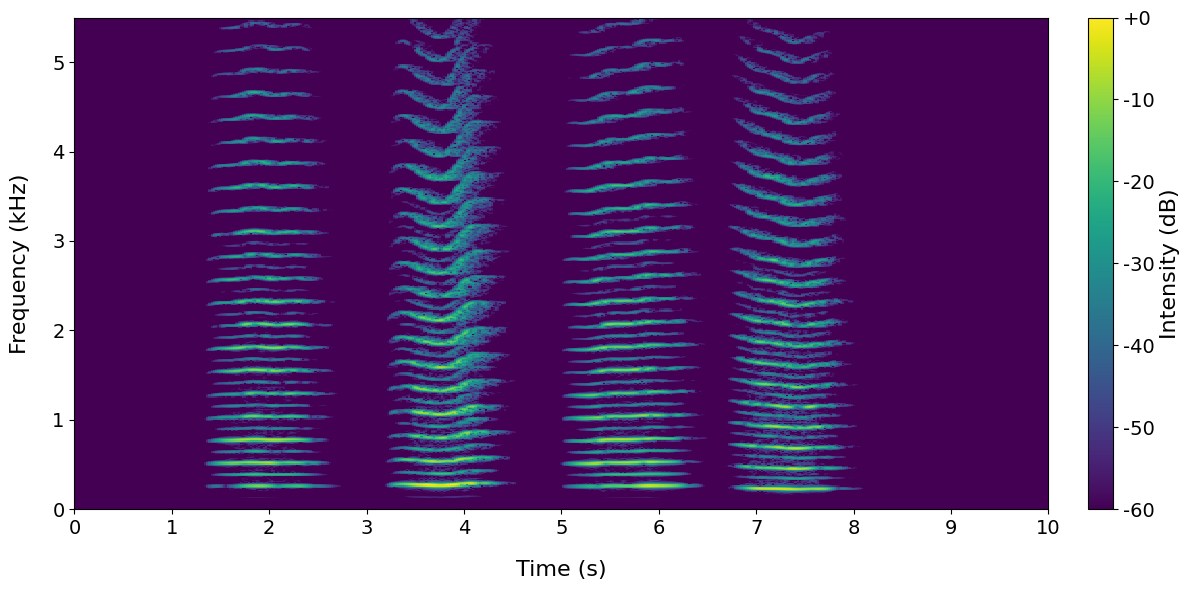

In [3]:
# Spectrogram Plot
plot_spectrogram(
    whale_calls_real, SAMPLING_RATE, n_fft=4096, hop_length=1024, y_lim=(0, 5500)
)

# Audio
display(Audio(data=whale_calls_real, rate=SAMPLING_RATE))

# Snapping Shrimp

In [14]:
shrimp_source = GroundTruthState(
    [0, 0, 0, 0, -50, 0],
    timestamp=datetime.now(),
    metadata={
        'amplitude_upa': 10**(195 / 20),
        'position_mapping': [0, 2, 4],
    }
)

effects = [Reverb(duration_s=0.1, wet_dry_mix=0.9)]

shrimp_signal_model = DiffuseSnappingShrimpSignal(
    duration_s = SIGNAL_DURATION,
    sampling_rate_hz = SAMPLING_RATE,
    num_diffuse_sources = 1000,
    colony_radius_m = 100,
    temperature_celsius = 25,
    start_time_hours = 18.0,
    diurnal_amplitude = 0.25,
    diurnal_phase_hours = 6,
    delay_duration = 0.0006,
    onset_duration = 0.0001,
    snap_duration = 0.0014,
    onset_level = 0.15,
    onset_freq = 2500,
    snap_decay = 1000,
    low_cutoff_hz = 1500,
    high_cutoff_hz = 10000,
    ssp = Munk()
)

shrimp_signal = shrimp_signal_model.generate(
    source=shrimp_source,
    sensor_delays_s=np.array([0.0]),
    tloss_db=80.0,
    propagation_time_s=10.0,
)
shrimp_signal_real = np.real(shrimp_signal[0, :])

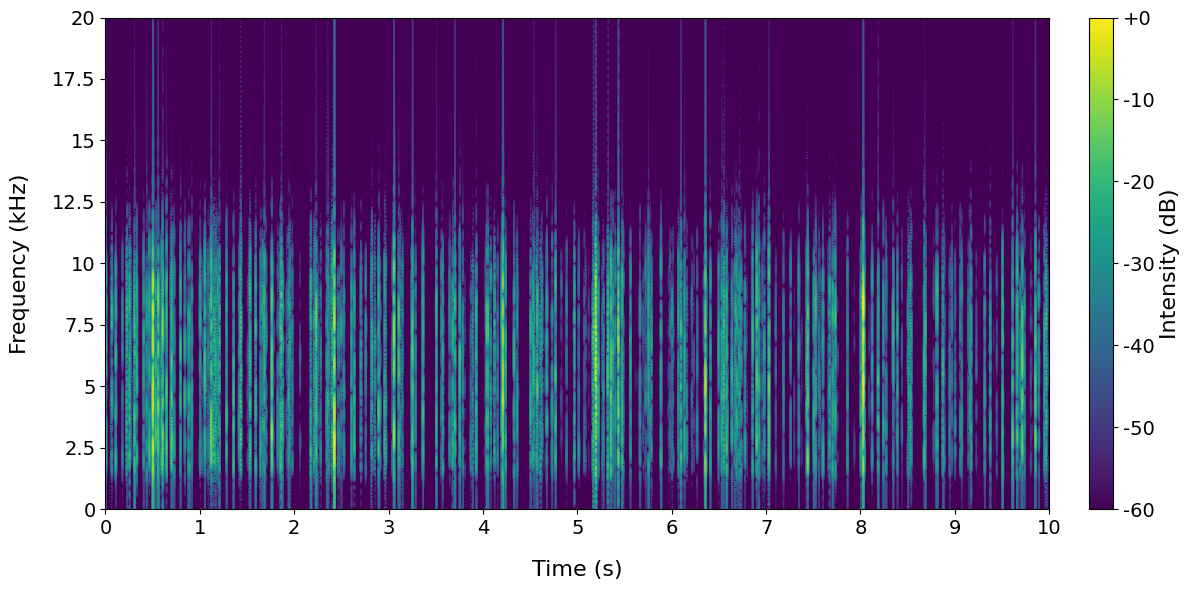

In [15]:
# Spectrogram Plot
plot_spectrogram(
    shrimp_signal_real, SAMPLING_RATE, n_fft=2048, hop_length=512, y_lim=(0, 20000)
)

# Audio
display(Audio(data=shrimp_signal_real, rate=SAMPLING_RATE))

# Commerical Vessel

In [16]:
target_states = [GroundTruthState(
    [0, 0, 0, 0, -10, 0],
    timestamp=datetime.now(),
    metadata={
        "frequencies_hz": np.array([
            # --- Low-Frequency Prop/Engine Tonals ---
            # Urick, R. J. (1983). Principles of underwater sound.
            50.0,   # 4th Blade Rate Harmonic + Main Machinery
            75.0,   # 6th Blade Rate Harmonic
            125.0,  # 10th Blade Rate Harmonic
            82.0,   # Unrelated secondary machinery
        ]),
        # Amplitudes (Source Levels) in dB re 1uPa @ 1m.
        "amplitudes_upa": 10 ** (np.array([175.0, 168.0, 162.0, 160.0,]) / 20),
        "phases_rad": np.random.uniform(0, 2 * np.pi, 4),
        'position_mapping': [0, 2, 4],
    }
)]

tonal_signal = TonalSignal(
    duration_s=SIGNAL_DURATION,
    sampling_rate_hz=SAMPLING_RATE,
).generate(
    source=target_states[0],
    sensor_delays_s=np.array([0.0]),
    tloss_db=60.0,
    propagation_time_s=0.0
)

tonal_signal_real = np.real(tonal_signal[0, :])

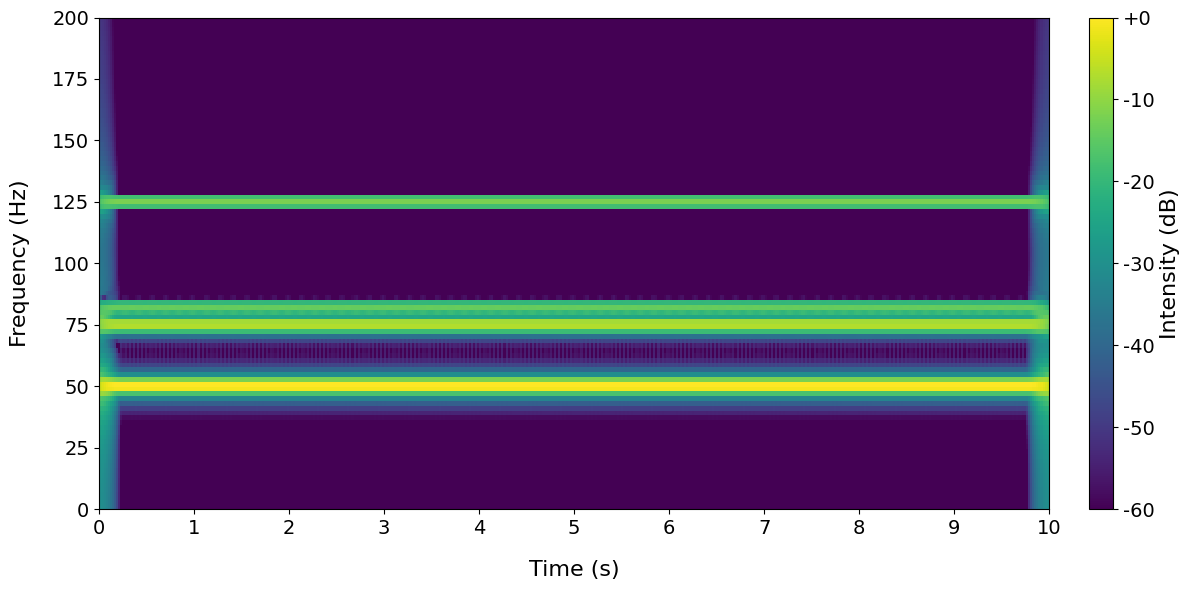

In [17]:
# Spectrogram Plot
plot_spectrogram(
    tonal_signal_real,
    SAMPLING_RATE,
    n_fft=4096*6,
    hop_length=1024,
    y_lim=(0, 200),
    yaxis_format="hz"
)

# Audio
display(Audio(data=tonal_signal_real, rate=SAMPLING_RATE))

# Ambient Background Noise

In [18]:
ambient_noise = WhiteNoise(
    amplitude_upa=10**(90 / 20),
    duration_s=SIGNAL_DURATION,
    sampling_rate_hz=SAMPLING_RATE
).generate()

ambient_noise_real = np.real(ambient_noise[0, :])

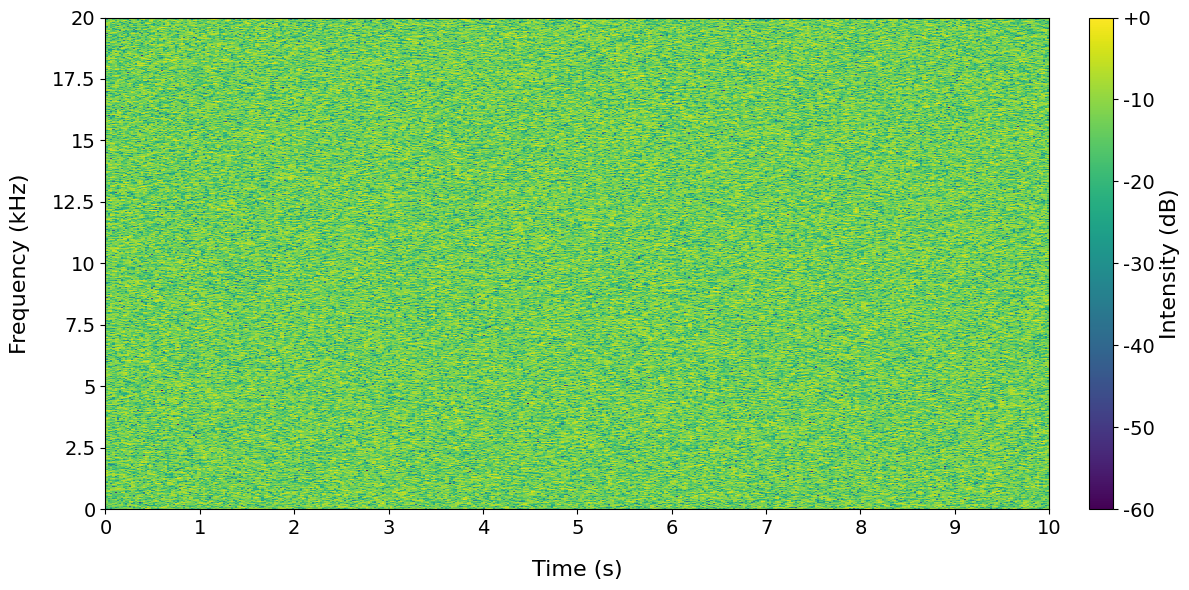

In [19]:
# Spectrogram Plot
plot_spectrogram(
    ambient_noise_real,
    SAMPLING_RATE,
    n_fft=4096,
    hop_length=1024,
    y_lim=(0, 20000),
    yaxis_format="kHz"
)

# Audio
display(Audio(data=ambient_noise_real, rate=SAMPLING_RATE))

# Soundscape

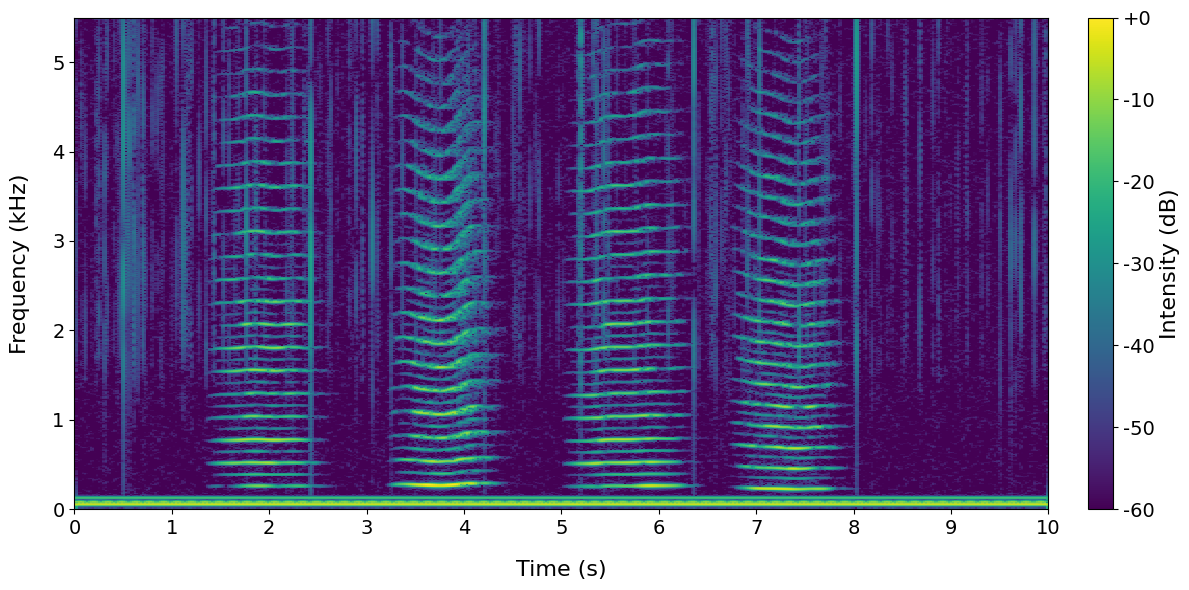

In [20]:
# Add all signals together
soundscape = whale_calls_real + shrimp_signal_real + tonal_signal_real + ambient_noise_real

# Plot Spectrogram
plot_spectrogram(
    soundscape,
    SAMPLING_RATE,
    n_fft=4096,
    hop_length=1024,
    y_lim=(0, 5500)
)

# Display Audio Player
display(Audio(data=soundscape, rate=SAMPLING_RATE))